# Importing libraries and Dataset

In [3]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt 
import warnings
warnings.filterwarnings("ignore")
df=pd.read_csv(r"C:\Users\wwwsh\OneDrive\Desktop\proj_1\data_sci\seaborn_proj\IPL.csv")

## Printing first 5 lines

In [8]:
df.head()

,match_id,date,venue,team1,team2,stage,toss_winner,toss_decision,first_ings_score,first_ings_wkts,second_ings_score,second_ings_wkts,match_winner,won_by,margin,player_of_the_match,top_scorer,highscore,best_bowling,best_bowling_figure
0,1,"March 26,2022","Wankhede Stadium, Mumbai",Chennai,Kolkata,Group,Kolkata,Field,131,5,133,4,Kolkata,Wickets,6,Umesh Yadav,MS Dhoni,50,Dwayne Bravo,3--20
1,2,"March 27,2022","Brabourne Stadium, Mumbai",Delhi,Mumbai,Group,Delhi,Field,177,5,179,6,Delhi,Wickets,4,Kuldeep Yadav,Ishan Kishan,81,Kuldeep Yadav,3--18
2,3,"March 27,2022","Dr DY Patil Sports Academy, Mumbai",Banglore,Punjab,Group,Punjab,Field,205,2,208,5,Punjab,Wickets,5,Odean Smith,Faf du Plessis,88,Mohammed Siraj,2--59
3,4,"March 28,2022","Wankhede Stadium, Mumbai",Gujarat,Lucknow,Group,Gujarat,Field,158,6,161,5,Gujarat,Wickets,5,Mohammed Shami,Deepak Hooda,55,Mohammed Shami,3--25
4,5,"March 29,2022","Maharashtra Cricket Association Stadium,Pune",Hyderabad,Rajasthan,Group,Hyderabad,Field,210,6,149,7,Rajasthan,Runs,61,Sanju Samson,Aiden Markram,57,Yuzvendra Chahal,3--22


## Basic Info

In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 74 entries, 0 to 73
Data columns (total 20 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   match_id             74 non-null     int64 
 1   date                 74 non-null     object
 2   venue                74 non-null     object
 3   team1                74 non-null     object
 4   team2                74 non-null     object
 5   stage                74 non-null     object
 6   toss_winner          74 non-null     object
 7   toss_decision        74 non-null     object
 8   first_ings_score     74 non-null     int64 
 9   first_ings_wkts      74 non-null     int64 
 10  second_ings_score    74 non-null     int64 
 11  second_ings_wkts     74 non-null     int64 
 12  match_winner         74 non-null     object
 13  won_by               74 non-null     object
 14  margin               74 non-null     int64 
 15  player_of_the_match  74 non-null     object
 16  top_scorer

All the coloumns, their datatypes and number of null or non null values are displayed above


## Size and shape

In [ ]:
df.shape

(74, 20)

 it has 74 rows and 20 coloumns 

for better representation , check below

In [20]:
print(f"No. of rows = {df.shape[0]} \nNo. of columns = {df.shape[1]}")

No. of rows = 74 
No. of columns = 20


## Check again for any null values 

In [21]:
df.isnull().sum(    )

match_id               0
date                   0
venue                  0
team1                  0
team2                  0
stage                  0
toss_winner            0
toss_decision          0
first_ings_score       0
first_ings_wkts        0
second_ings_score      0
second_ings_wkts       0
match_winner           0
won_by                 0
margin                 0
player_of_the_match    0
top_scorer             0
highscore              0
best_bowling           0
best_bowling_figure    0
dtype: int64

This shows that there are no null values in the dataset

# 1) Team with most wins

In [ ]:
match_w=df["match_winner"].value_counts()
df["match_winner"].value_counts().head(1)

match_winner
Gujarat    12
Name: count, dtype: int64

Gujrat had max wins

In [33]:
match_w

match_winner
Gujarat      12
Rajasthan    10
Banglore      9
Lucknow       9
Punjab        7
Delhi         7
Kolkata       6
Hyderabad     6
Chennai       4
Mumbai        4
Name: count, dtype: int64

## Plotting it in graph

Text(0.5, 0, 'Wins')

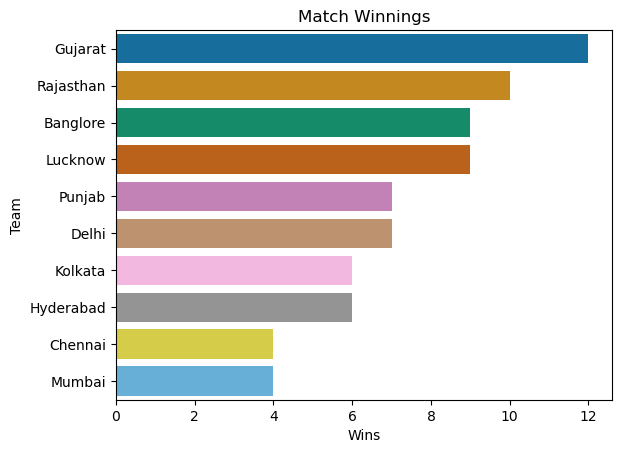

In [44]:
sns.barplot(y=match_w.index,x=match_w.values,palette="colorblind")
plt.title("Match Winnings")
plt.ylabel("Team")
plt.xlabel("Wins")

# 2) Toss decision trend

Text(0.5, 0, 'count')

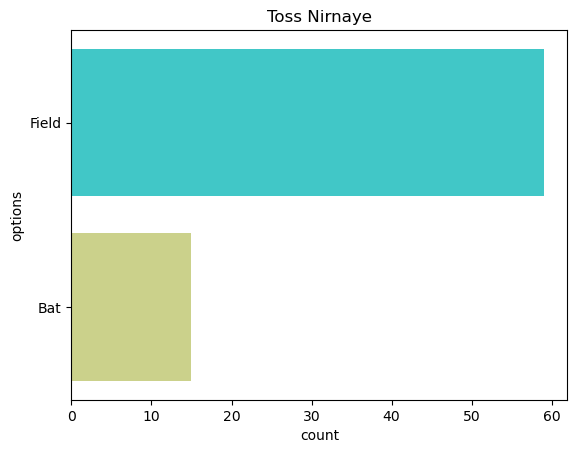

In [51]:
sns.countplot(df["toss_decision"],palette="rainbow")
plt.title("Toss Nirnaye")
plt.ylabel("options")
plt.xlabel("count")


# 3) Toss vs Match vijeta

basically , number of teams winning match fter winning toss

In [54]:
toss_w=df["toss_winner"].value_counts()
match_w=df["match_winner"].value_counts()

yeh upar wala aise he likha

In [60]:
ganit=df[df["toss_winner"]==df["match_winner"]]['match_id'].count()
percentage=(ganit*100)/df.shape[0]
        #   (count*100)/total number of matches
percentage.round(2)

np.float64(48.65)

this shows that a total of 36 matches hua , where match is won by toss win team 

# 4)How teams won (Runs vs Wickets) ?

Text(0, 0.5, 'count')

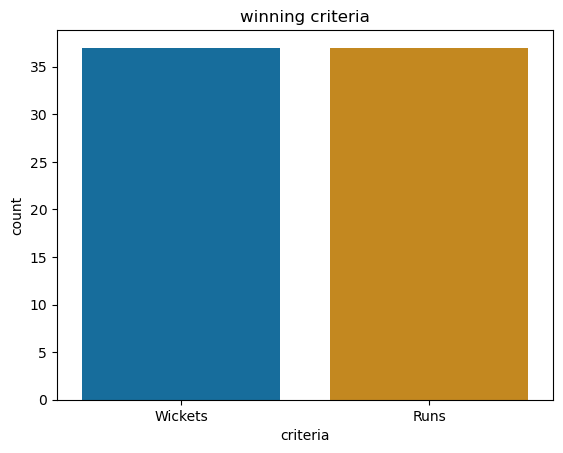

In [64]:
sns.countplot(x=df["won_by"],palette=("colorblind"))
plt.title("winning criteria")
plt.xlabel("criteria")
plt.ylabel("count")

# 5) Key player performances 

## i) Most "Player of the match" award

In [73]:
val=df["player_of_the_match"].value_counts().head(5)
val

player_of_the_match
Kuldeep Yadav        4
Jos Buttler          3
Wanindu Hasaranga    2
Umesh Yadav          2
Quinton de Kock      2
Name: count, dtype: int64

Text(0.5, 1.0, 'Top 5 Player of the match')

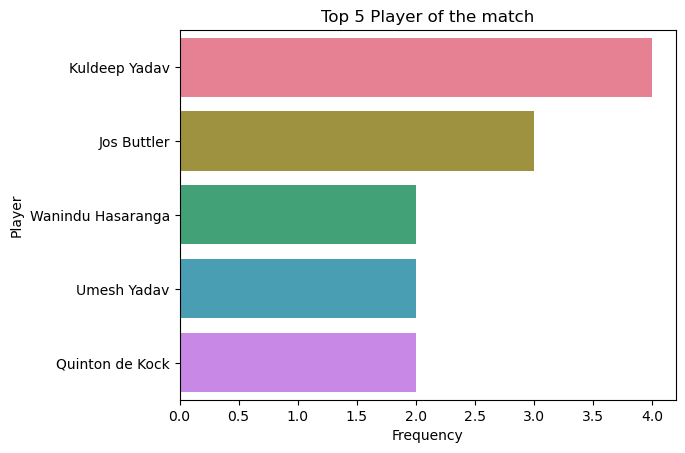

In [83]:
sns.barplot(x=val.values,y=val.index,palette="husl")
plt.xlabel("Frequency")
plt.ylabel("Player")
plt.title("Top 5 Player of the match")

## ii) 2 Top scorers 

top scorer with highest runs basically


In [104]:
ankh=df.groupby('top_scorer')['highscore'].sum().sort_values(ascending=False)
ankh.head(2)
score=ankh.head(2)
score

top_scorer
Jos Buttler        651
Quinton de Kock    377
Name: highscore, dtype: int64

<Axes: ylabel='top_scorer'>

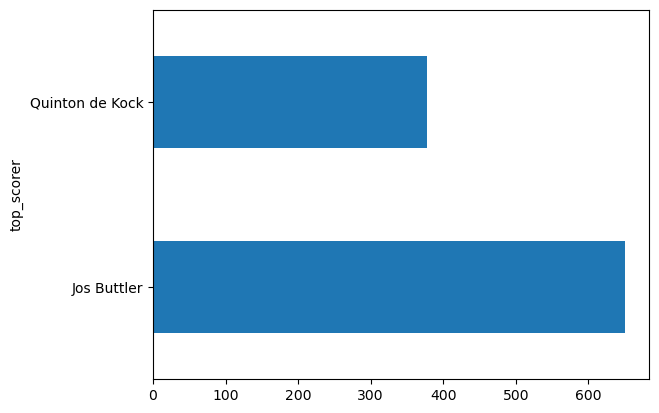

In [103]:
score.plot(kind='barh')

## iii) 10 best bowling fig

below is the lamba expression for . . . 


In [4]:
df['Max_wickets']=df['best_bowling_figure'].apply(lambda x :x.split('--')[0])
# the above line seperates the "wickets" taken by "best_bowling" from "best_bowling_figure"
df['Max_wickets']=df['Max_wickets'].astype(int)

<Axes: ylabel='best_bowling'>

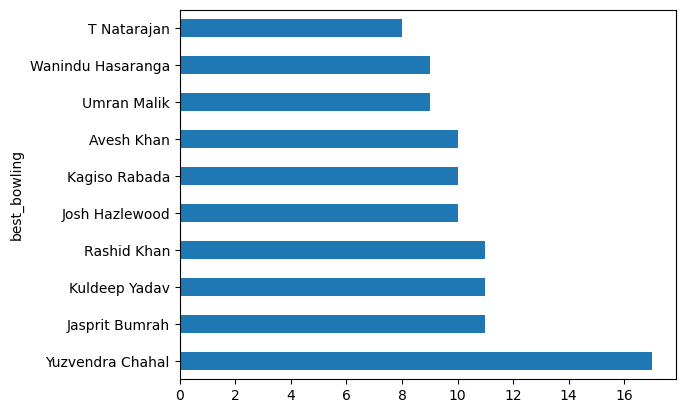

In [10]:
ball=df.groupby('best_bowling')['Max_wickets'].sum().sort_values(ascending=False).head(10)
ball.plot(kind='barh')

# 6) Sthan Vichar

## i) Most matches played by venue

In [11]:
sthan=df['venue'].value_counts()
sthan

venue
Wankhede Stadium, Mumbai                        21
Dr DY Patil Sports Academy, Mumbai              20
Brabourne Stadium, Mumbai                       16
Maharashtra Cricket Association Stadium,Pune    13
Eden Gardens, Kolkata                            2
Narendra Modi Stadium, Ahmedabad                 2
Name: count, dtype: int64

<Axes: ylabel='venue'>

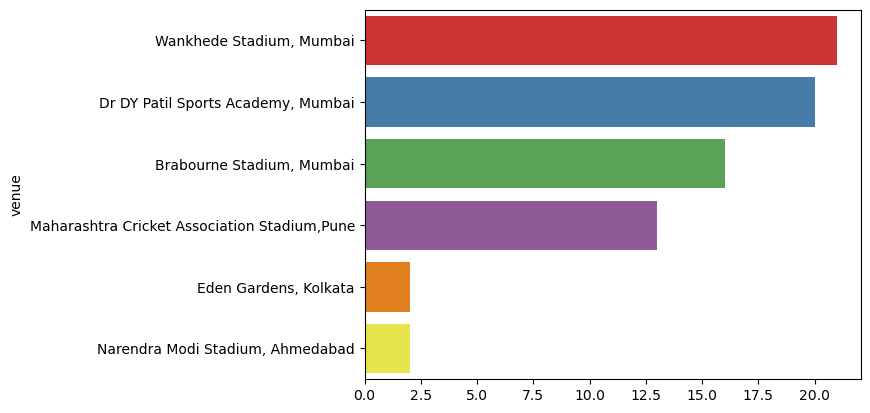

In [15]:
sns.barplot(y=sthan.index,x=sthan.values,palette="Set1")

# Extras

## 1) Who won the highest margin by runs 

In [25]:
df[df["won_by"]=="Runs"].sort_values(by="margin",ascending=False).head(1)[['match_winner','margin']]

,match_winner,margin
54,Chennai,91


## 2) Which player had highest individual score ?

In [37]:
df[df['highscore']==df['highscore'].max()][['top_scorer']]

,top_scorer
65,Quinton de Kock


## 3) Which bowler had best bowling features ?

In [53]:
df[df["Max_wickets"] == df["Max_wickets"].max()][['best_bowling','best_bowling_figure']].sort_values(by="best_bowling_figure", ascending=True).head(1)


,best_bowling,best_bowling_figure
55,Jasprit Bumrah,5--10
